In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
os.listdir("drive/MyDrive/data/")

['employee_salary_200.csv',
 'House-Prediction_Dataset',
 'corona prediction data',
 'titanic data set',
 'car_price_dataset.csv',
 'boxcox_practice_data.csv',
 'transform_practice_data.csv',
 'Movie-Recommendation-System',
 'house_price_missing.csv',
 'student_performance_missing.csv',
 'house_price_zscore_practice.csv']

In [4]:
path = "/content/drive/MyDrive/data/house_price_zscore_practice.csv"

In [5]:
import numpy as np
import pandas as pd


In [6]:
df = pd.read_csv(path)

In [7]:
df.head()

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
0,1040.3,1,1,10.0,0.42,114.78
1,1645.4,3,3,1.3,12.16,201.66
2,19252.0,4,3,0.2,0.30,250.06
3,1764.0,3,2,2.5,3.61,202.62
4,1703.8,3,2,14.3,22.68,188.63


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='bathrooms', ylabel='Count'>

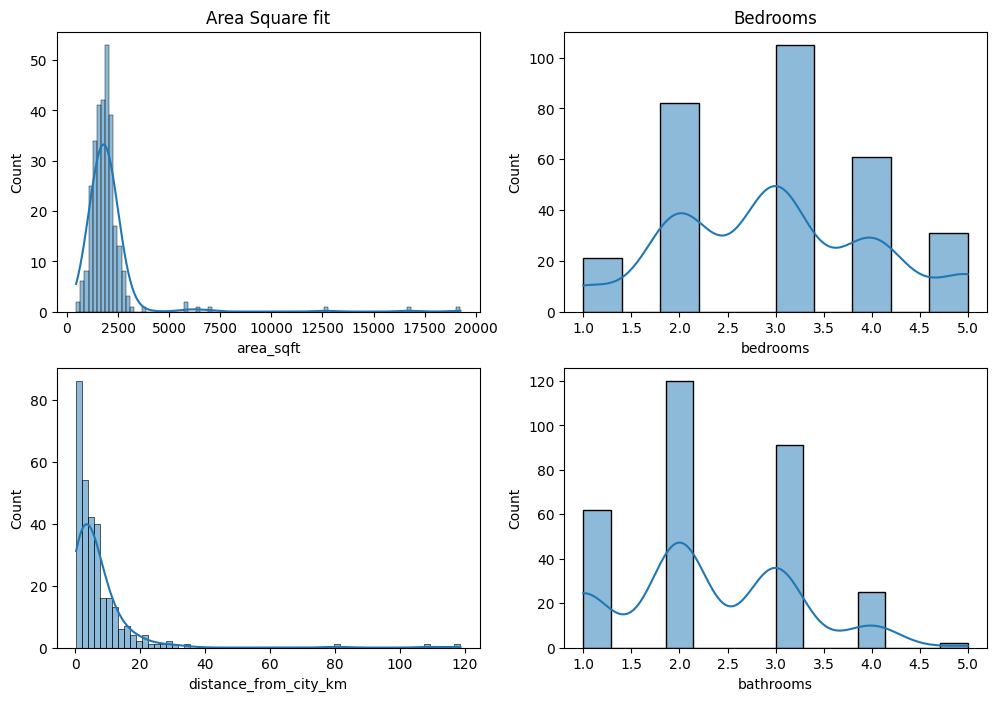

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

flat = axes.flatten()

sns.histplot(df["area_sqft"], kde=True, ax=flat[0])
flat[0].set_title("Area Square fit")

sns.histplot(df["bedrooms"], kde=True, ax=flat[1])
flat[1].set_title("Bedrooms")

sns.histplot(df["distance_from_city_km"], kde=True, ax=flat[2])

sns.histplot(df["bathrooms"], kde=True, ax=flat[3])


<Axes: ylabel='bathrooms'>

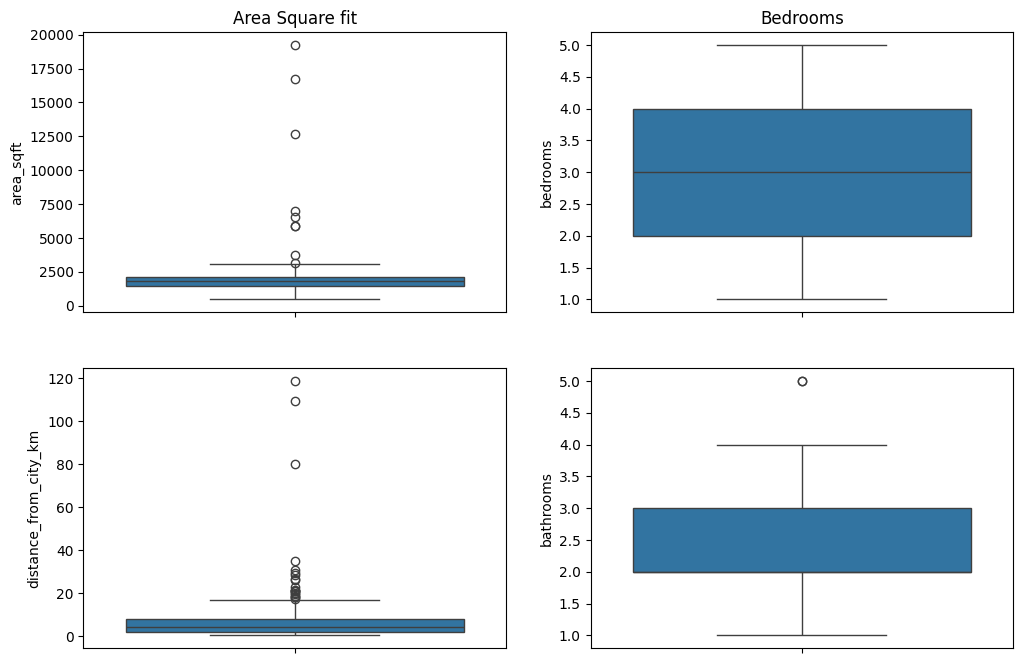

In [27]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

flat = axes.flatten()

sns.boxplot(df["area_sqft"], ax=flat[0])
flat[0].set_title("Area Square fit")

sns.boxplot(df["bedrooms"], ax=flat[1])
flat[1].set_title("Bedrooms")

sns.boxplot(df["distance_from_city_km"], ax=flat[2])

sns.boxplot(df["bathrooms"], ax=flat[3])


# Without Zero Scoring

In [10]:
X = df.drop("price_in_thousands", axis=1)
Y = df["price_in_thousands"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression


In [21]:
model = LinearRegression()

In [22]:
model.fit(x_train_scaled, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(x_test_scaled)

In [24]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.43152033930597333

# Z-Score Outlier Treatment

In [31]:
new_df = df

In [32]:
new_df

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
0,1040.3,1,1,10.0,0.42,114.78
1,1645.4,3,3,1.3,12.16,201.66
2,19252.0,4,3,0.2,0.30,250.06
3,1764.0,3,2,2.5,3.61,202.62
4,1703.8,3,2,14.3,22.68,188.63
...,...,...,...,...,...,...
295,2367.8,2,1,4.9,1.93,277.26
296,2301.8,4,3,1.1,16.30,239.21
297,1855.5,5,3,9.1,4.34,247.14
298,1358.1,3,2,20.3,0.30,179.42


In [58]:
new_df["area_sqft"] = np.log1p(new_df["area_sqft"])
new_df["distance_from_city_km"] = np.log1p(new_df["distance_from_city_km"])
new_df["age_years"] = np.log1p(new_df["age_years"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: ylabel='age_years'>

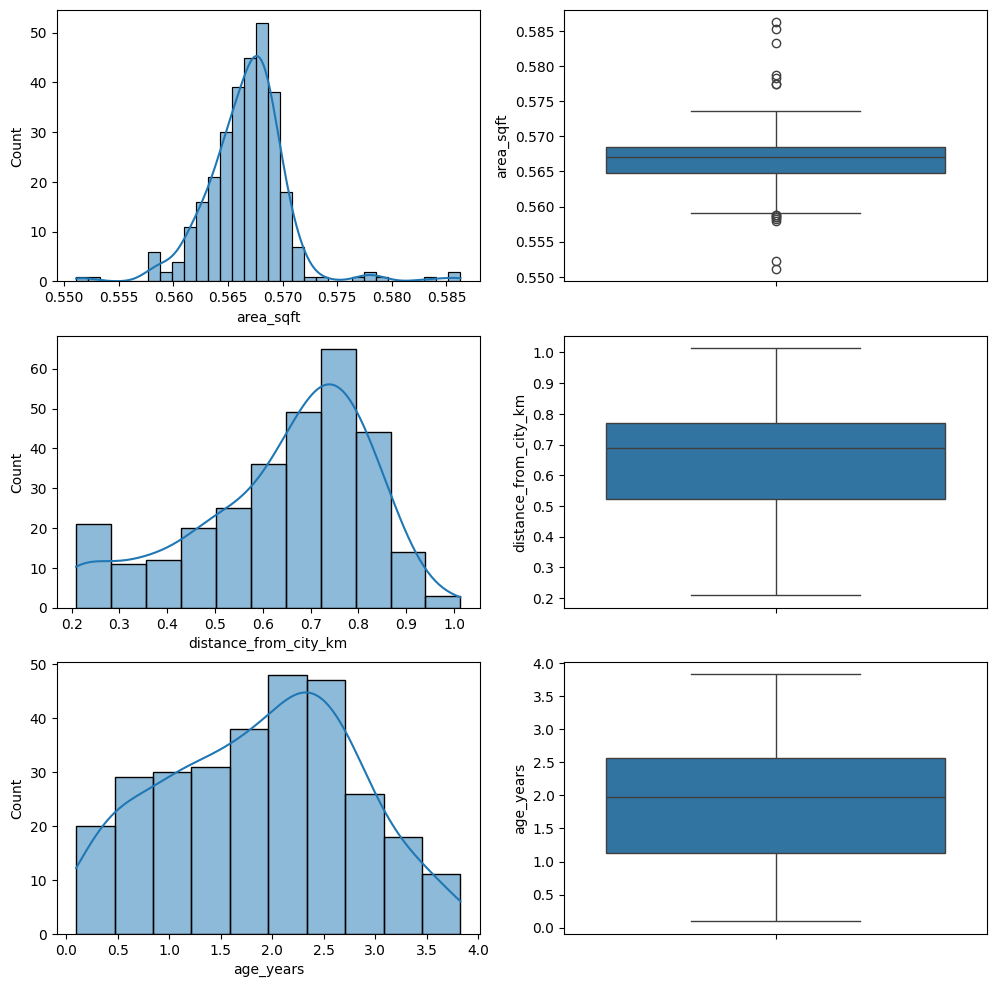

In [59]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12,12)
)

flat = axes.flatten()

sns.histplot(new_df["area_sqft"], kde=True, ax=flat[0])

sns.boxplot(new_df["area_sqft"], ax=flat[1])

sns.histplot(new_df["distance_from_city_km"], kde=True, ax=flat[2])

sns.boxplot(new_df["distance_from_city_km"], ax=flat[3])

sns.histplot(new_df["age_years"], ax=flat[4], kde=True)
sns.boxplot(new_df["age_years"], ax=flat[5])


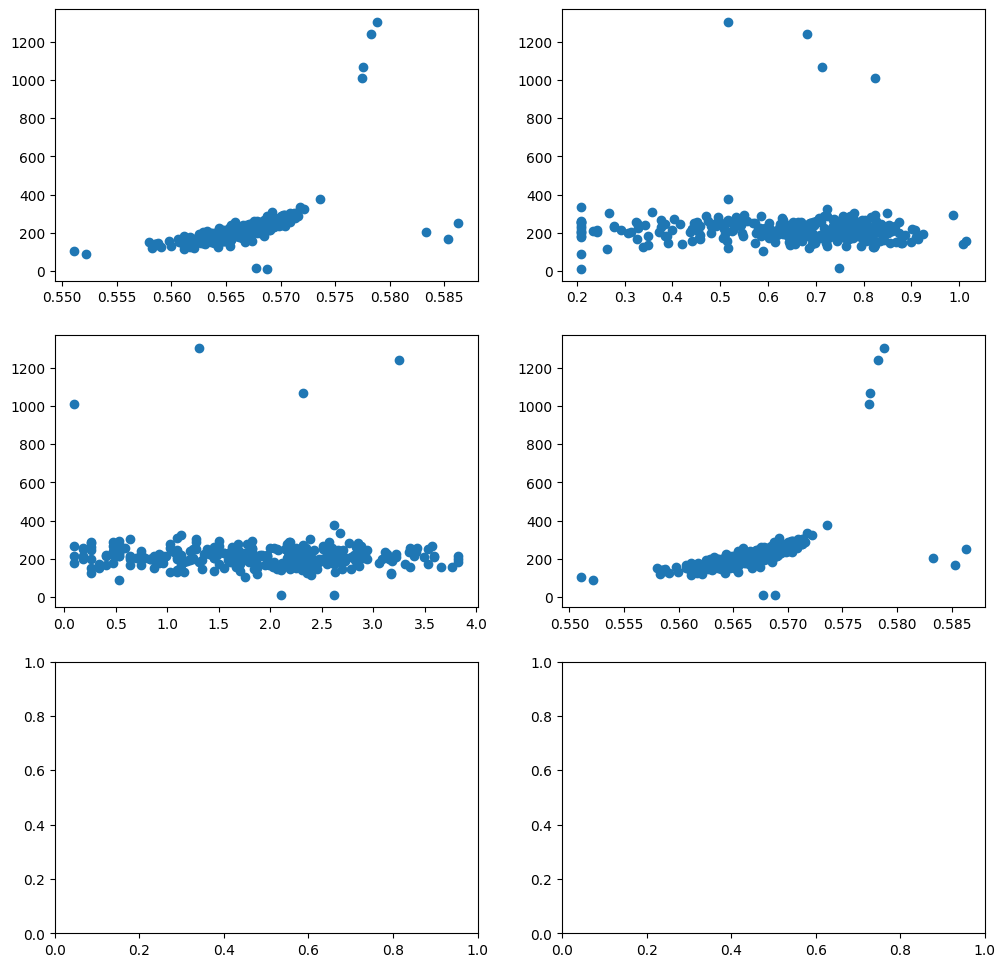

In [ ]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12,12)
)

flat = axes.flatten()

flat[0].scatter(new_df["area_sqft"], new_df["price_in_thousands"])
flat[1].scatter(new_df["distance_from_city_km"], new_df["price_in_thousands"])
flat[2].scatter(new_df["age_years"], new_df["price_in_thousands"])
flat[3].scatter(new_df["area_sqft"], new_df["price_in_thousands"])


In [75]:
new_df.dropna(inplace=True)

In [76]:
new_x = new_df.drop("price_in_thousands", axis=1)
new_y = new_df["price_in_thousands"]

In [77]:
new_df.isna().sum()

,0
area_sqft,0
bedrooms,0
bathrooms,0
age_years,0
distance_from_city_km,0
price_in_thousands,0


In [78]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(new_x, new_y, test_size=0.2, random_state=42)

In [79]:
model = LinearRegression()

model.fit(X_train_new, y_train_new)

y_pred_new = model.predict(X_test_new)

r2_score(y_test_new, y_pred_new)

-1.1177597115214088

In [80]:
new_df.head()

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
0,0.561134,1,1,2.397895,0.262819,114.78
1,0.565960,3,3,0.832909,0.821793,201.66
2,0.586282,4,3,0.182322,0.209439,250.06
3,0.566657,3,2,1.252763,0.656233,202.62
4,0.566310,3,2,2.727853,0.886502,188.63


In [88]:
from scipy.stats import zscore

In [94]:
cols = ["age_years", "distance_from_city_km", "area_sqft"]

In [95]:
z_scores = new_df[cols].apply(zscore)

In [96]:
z_scores

,age_years,distance_from_city_km,area_sqft
0,0.568842,-2.037860,-1.468140
1,-1.143109,0.985821,-0.197872
2,-1.854793,-2.326608,5.151912
3,-0.683828,0.090252,-0.014398
4,0.929786,1.335855,-0.105639
...,...,...,...
295,-0.112600,-0.494680,0.736595
296,-1.242624,1.158270,0.666171
297,0.475467,0.246574,0.117456
298,1.291710,-2.326608,-0.716149


In [97]:
outliers_rows = (abs(z_scores) > 3).any(axis=1)

In [98]:
new_df_clean = df[~outliers_rows]

In [102]:
new_df_clean.drop(["area_z", "distance_z", "age_z"], inplace=True, axis=1)

/tmp/ipykernel_2730/1483642015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df_clean.drop(["area_z", "distance_z", "age_z"], inplace=True, axis=1)


In [104]:
new_df_clean

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
0,0.561134,1,1,2.397895,0.262819,114.78
1,0.565960,3,3,0.832909,0.821793,201.66
3,0.566657,3,2,1.252763,0.656233,202.62
4,0.566310,3,2,2.727853,0.886502,188.63
5,0.567165,2,2,1.131402,0.744889,220.61
...,...,...,...,...,...,...
295,0.569510,2,1,1.774952,0.548100,277.26
296,0.569242,4,3,0.741937,0.853673,239.21
297,0.567158,5,3,2.312535,0.685132,247.14
298,0.563991,3,2,3.058707,0.209439,179.42


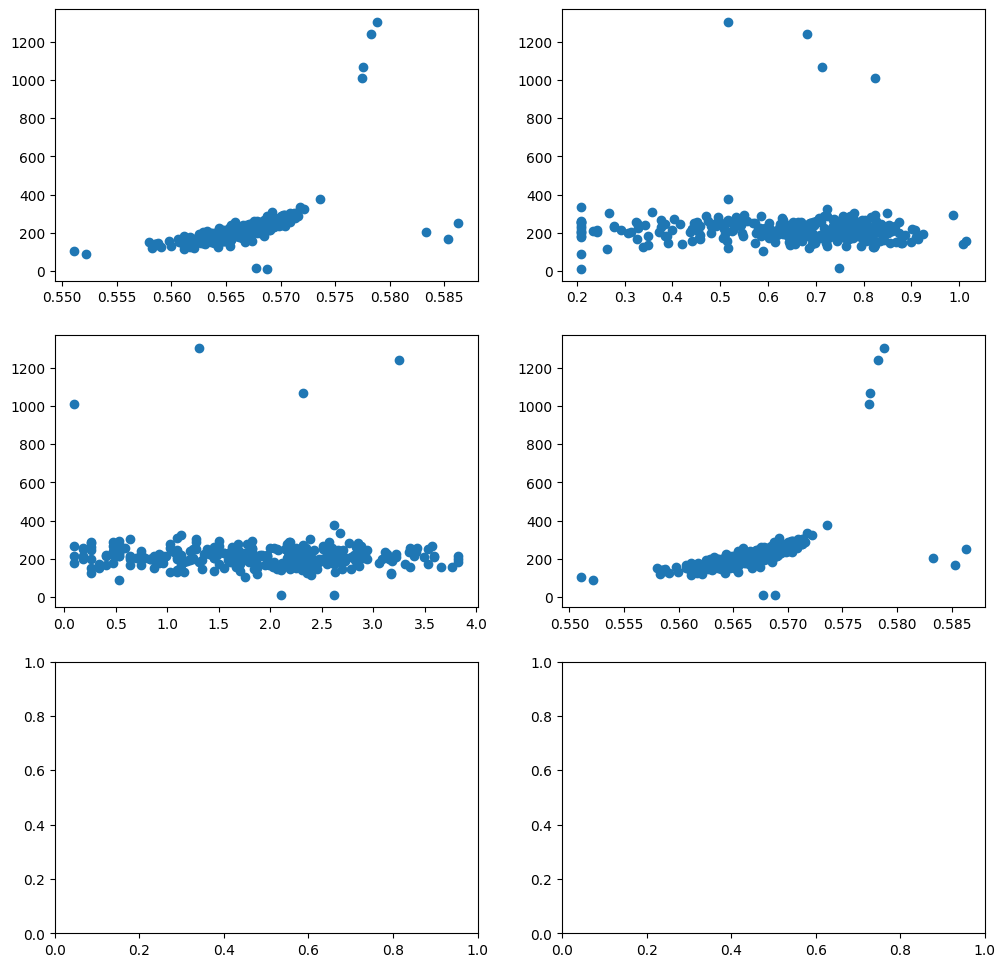

In [117]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12,12)
)

flat = axes.flatten()

flat[0].scatter(new_df["area_sqft"], new_df["price_in_thousands"])
flat[1].scatter(new_df["distance_from_city_km"], new_df["price_in_thousands"])
flat[2].scatter(new_df["age_years"], new_df["price_in_thousands"])
flat[3].scatter(new_df["area_sqft"], new_df["price_in_thousands"])


In [108]:
X = new_df_clean[["area_sqft",	"bedrooms",	"bathrooms",	"age_years",	"distance_from_city_km"]]
y= new_df_clean["price_in_thousands"]

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,      # 20% test data
    random_state=42     # for reproducibility
)


In [112]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [115]:
y_pred = model.predict(X_test)

In [116]:
score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.18226658907607318
